In [27]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [3]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\2460133\OneDrive - Cognizant\Desktop\MLops\Recommendation System
['amazon_prime_titles.csv', 'model.ipynb', 'test.py', 'venv']


In [5]:
df = pd.read_csv("amazon_prime_titles.csv")
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...
5,s6,Movie,Living With Dinosaurs,Paul Weiland,"Gregory Chisholm, Juliet Stevenson, Brian Hens...",United Kingdom,"March 30, 2021",1989,NaN,52 min,"Fantasy, Kids",The story unfolds in a an English seaside town...
6,s7,Movie,Hired Gun,Fran Strine,"Alice Cooper, Liberty DeVitto, Ray Parker Jr.,...",United States,"March 30, 2021",2017,NaN,98 min,"Documentary, Special Interest","They are the ""First Call, A-list"" musicians, j..."
7,s8,Movie,Grease Live!,"Thomas Kail, Alex Rudzinski","Julianne Hough, Aaron Tveit, Vanessa Hudgens, ...",United States,"March 30, 2021",2016,NaN,131 min,Comedy,"This honest, uncompromising comedy chronicles ..."
8,s9,Movie,Global Meltdown,Daniel Gilboy,"Michael Paré, Leanne Khol Young, Patrick J. Ma...",Canada,"March 30, 2021",2017,NaN,87 min,"Action, Science Fiction, Suspense",A helicopter pilot and an environmental scient...
9,s10,Movie,David's Mother,Robert Allan Ackerman,"Kirstie Alley, Sam Waterston, Stockard Channing",United States,"April 1, 2021",1994,NaN,92 min,Drama,Sally Goodson is a devoted mother to her autis...


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       9668 non-null   str  
 1   type          9668 non-null   str  
 2   title         9668 non-null   str  
 3   director      7585 non-null   str  
 4   cast          8435 non-null   str  
 5   country       672 non-null    str  
 6   date_added    155 non-null    str  
 7   release_year  9668 non-null   int64
 8   rating        9331 non-null   str  
 9   duration      9668 non-null   str  
 10  listed_in     9668 non-null   str  
 11  description   9668 non-null   str  
dtypes: int64(1), str(11)
memory usage: 906.5 KB


In [29]:
df.isnull()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9663,False,False,False,False,False,True,True,False,False,False,False,False
9664,False,False,False,True,False,True,True,False,False,False,False,False
9665,False,False,False,False,False,True,True,False,False,False,False,False
9666,False,False,False,True,False,True,True,False,False,False,False,False


In [23]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2083
cast            1233
country         8996
date_added      9513
release_year       0
rating           337
duration           0
listed_in          0
description        0
dtype: int64

In [27]:
df[df['director'].isnull()]


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
17,s18,TV Show,Zoo Babies,NaN,Narrator - Gillian Barlett,NaN,NaN,2008,ALL,1 Season,"Kids, Special Interest",A heart warming and inspiring series that welc...
18,s19,TV Show,Zoë Coombs Marr: Bossy Bottom,NaN,Zoë Coombs Marr,NaN,NaN,2020,18+,1 Season,"Comedy, Talk Show and Variety",Zoë Coombs Marr has been on hiatus. Sort of. F...
20,s21,TV Show,Zoboomafoo,NaN,NaN,NaN,NaN,2001,TV-Y,1 Season,Kids,Chris and Martin Kratt bring their enthusiasm ...
21,s22,TV Show,Zo Zo Zombie: Mini-Series,NaN,"Alex Cazares, Ben Diskin, Cristina Vee, Erika ...",NaN,NaN,2020,TV-Y7,1 Season,"Action, Anime, Comedy","Zo Zo Zombie is our undead hero who, with his ..."
23,s24,TV Show,ZeroZeroZero,NaN,"ANDREA RISEBOROUGH, HAROLD TORRES, CLAUDIA PIN...",Italy,NaN,2020,18+,1 Season,TV Shows,ZeroZeroZero series follows the journey of a c...
...,...,...,...,...,...,...,...,...,...,...,...,...
9655,s9656,TV Show,DaFUNdamentals Series,NaN,"Emile Crawford, Randall Crawford, Jon Ward",NaN,NaN,2021,TV-Y,1 Season,"Animation, Kids","Learn ""daFundamentals"" through song and fun ch..."
9658,s9659,Movie,12 Dates of Christmas,NaN,NaN,NaN,NaN,2011,PG,87 min,"Drama, Romance","Setup on a Christmas Eve date, a woman must re..."
9661,s9662,TV Show,Terrahawks,NaN,"DENISE BRYER, WINDSOR DAVIES, JEREMY HITCHEN, ...",NaN,NaN,1983,ALL,3 Seasons,TV Shows,"This thrilling, action-packed series saw Gerry..."
9664,s9665,TV Show,Planet Patrol,NaN,"DICK VOSBURGH, RONNIE STEVENS, LIBBY MORRIS, M...",NaN,NaN,2018,13+,4 Seasons,TV Shows,"This is Earth, 2100AD - and these are the adve..."


In [ ]:
df.isna().sum()

show_id            0
type               0
title              0
director        2083
cast            1233
country         8996
date_added      9513
release_year       0
rating           337
duration           0
listed_in          0
description        0
dtype: int64

In [6]:
df["duration_min"] = pd.NA

mask = df["duration"].str.contains("min", na=False)

df.loc[mask, "duration_min"] = df.loc[mask, "duration"].str.extract(r'(\d+)')[0].astype(int)

In [7]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_min
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...,113
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...,110
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...,74
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ...",69
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9663,s9664,Movie,Pride Of The Bowery,Joseph H. Lewis,"Leo Gorcey, Bobby Jordan",NaN,NaN,1940,7+,60 min,Comedy,New York City street principles get an East Si...,60
9664,s9665,TV Show,Planet Patrol,NaN,"DICK VOSBURGH, RONNIE STEVENS, LIBBY MORRIS, M...",NaN,NaN,2018,13+,4 Seasons,TV Shows,"This is Earth, 2100AD - and these are the adve...",<NA>
9665,s9666,Movie,Outpost,Steve Barker,"Ray Stevenson, Julian Wadham, Richard Brake, M...",NaN,NaN,2008,R,90 min,Action,"In war-torn Eastern Europe, a world-weary grou...",90
9666,s9667,TV Show,Maradona: Blessed Dream,NaN,"Esteban Recagno, Ezequiel Stremiz, Luciano Vit...",NaN,NaN,2021,TV-MA,1 Season,"Drama, Sports","The series tells the story of Diego Maradona, ...",<NA>


In [8]:
print(df["type"].value_counts())

type
Movie      7814
TV Show    1854
Name: count, dtype: int64


In [9]:
null_check = df.groupby('type')["duration_min"].apply(lambda x: x.isnull().sum())
print(null_check)

type
Movie         0
TV Show    1854
Name: duration_min, dtype: int64


In [10]:
df["duration_min"] = df["duration_min"].fillna(0)


In [11]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_min
9663,s9664,Movie,Pride Of The Bowery,Joseph H. Lewis,"Leo Gorcey, Bobby Jordan",NaN,NaN,1940,7+,60 min,Comedy,New York City street principles get an East Si...,60
9664,s9665,TV Show,Planet Patrol,NaN,"DICK VOSBURGH, RONNIE STEVENS, LIBBY MORRIS, M...",NaN,NaN,2018,13+,4 Seasons,TV Shows,"This is Earth, 2100AD - and these are the adve...",0
9665,s9666,Movie,Outpost,Steve Barker,"Ray Stevenson, Julian Wadham, Richard Brake, M...",NaN,NaN,2008,R,90 min,Action,"In war-torn Eastern Europe, a world-weary grou...",90
9666,s9667,TV Show,Maradona: Blessed Dream,NaN,"Esteban Recagno, Ezequiel Stremiz, Luciano Vit...",NaN,NaN,2021,TV-MA,1 Season,"Drama, Sports","The series tells the story of Diego Maradona, ...",0
9667,s9668,Movie,Harry Brown,Daniel Barber,"Michael Caine, Emily Mortimer, Joseph Gilgun, ...",NaN,NaN,2010,R,103 min,"Action, Drama, Suspense","Harry Brown, starring two-time Academy Award w...",103


In [12]:
null_check = df.groupby('type')["duration_min"].apply(lambda x: x.isnull().sum())
print(null_check)

type
Movie      0
TV Show    0
Name: duration_min, dtype: int64


In [13]:
df['director'] = df['director'].fillna('')
df['cast'] = df['cast'].fillna('')
df['country'] = df['country'].fillna('')
df['rating'] = df['rating'].fillna('Unknown')
df['date_added']=df['date_added'].ffill()


In [14]:
df['date_added']=pd.to_datetime(df['date_added'], format= '%B %d, %Y')
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_min
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2021-03-30,2014,Unknown,113 min,"Comedy, Drama",A small fishing village must procure a local d...,113
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...,110
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,Unknown,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...,74
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,2021-03-30,2014,Unknown,69 min,Documentary,"Pink breaks the mold once again, bringing her ...",69
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,2021-03-30,1989,Unknown,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...,45


In [15]:
df['date_added']


0      2021-03-30
1      2021-03-30
2      2021-03-30
3      2021-03-30
4      2021-03-30
          ...    
9663   2021-10-10
9664   2021-10-10
9665   2021-10-10
9666   2021-10-10
9667   2021-10-10
Name: date_added, Length: 9668, dtype: datetime64[us]

In [16]:
df['rating'].unique()


<StringArray>
[ 'Unknown',      '13+',      'ALL',      '18+',        'R',     'TV-Y',
    'TV-Y7',       'NR',      '16+',    'TV-PG',       '7+',    'TV-14',
    'TV-NR',     'TV-G',    'PG-13',    'TV-MA',        'G',       'PG',
    'NC-17',  'UNRATED',       '16', 'AGES_16_', 'AGES_18_', 'ALL_AGES',
 'NOT_RATE']
Length: 25, dtype: str

In [17]:
df['rating']= df['rating'].replace({
    "NOT_RATE":"UNRATED",
    "AGES_16_":"16+",
    "16":"16+",
    "AGES_18_":"18+"
})

In [18]:
df['rating'].unique()


<StringArray>
[ 'Unknown',      '13+',      'ALL',      '18+',        'R',     'TV-Y',
    'TV-Y7',       'NR',      '16+',    'TV-PG',       '7+',    'TV-14',
    'TV-NR',     'TV-G',    'PG-13',    'TV-MA',        'G',       'PG',
    'NC-17',  'UNRATED', 'ALL_AGES']
Length: 21, dtype: str

In [19]:
df['type'].value_counts()
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_min
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2021-03-30,2014,Unknown,113 min,"Comedy, Drama",A small fishing village must procure a local d...,113
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...,110
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,Unknown,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...,74
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,2021-03-30,2014,Unknown,69 min,Documentary,"Pink breaks the mold once again, bringing her ...",69
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,2021-03-30,1989,Unknown,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...,45


In [20]:
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')
release_year_data = df.dropna(subset=['release_year'])

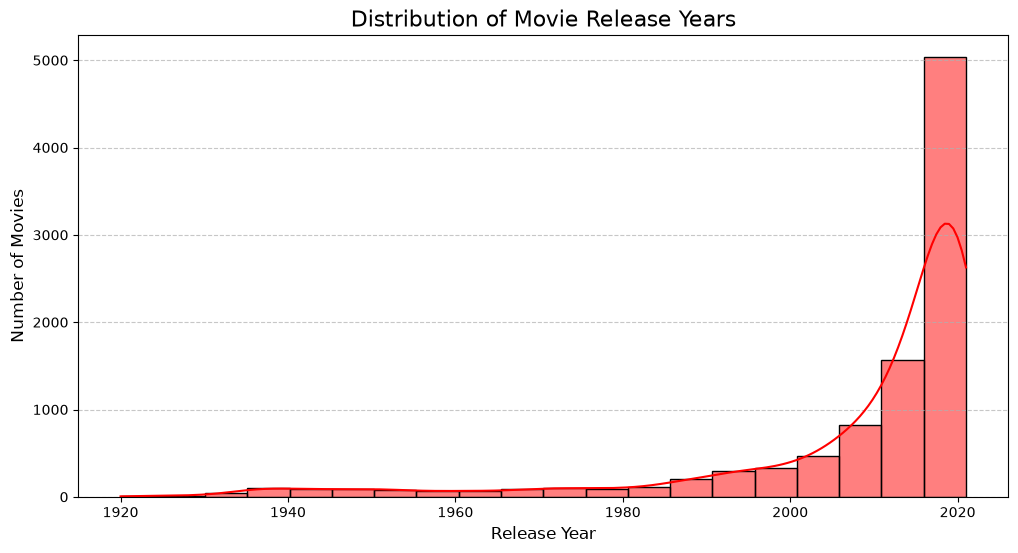

In [23]:
plt.figure(figsize=(12, 6))
sns.histplot(release_year_data['release_year'], bins=20, kde=True, color='red')
plt.title('Distribution of Movie Release Years', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [28]:
genres = df['listed_in'].dropna().str.split(', ')
all_genres = [genre for sublist in genres for genre in sublist]
genre_counts = Counter(all_genres)

In [29]:
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values(by='Count', ascending=False)

C:\Users\2460133\AppData\Local\Temp\ipykernel_17972\3616209771.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Genre', data=genre_df.head(10), palette='viridis')


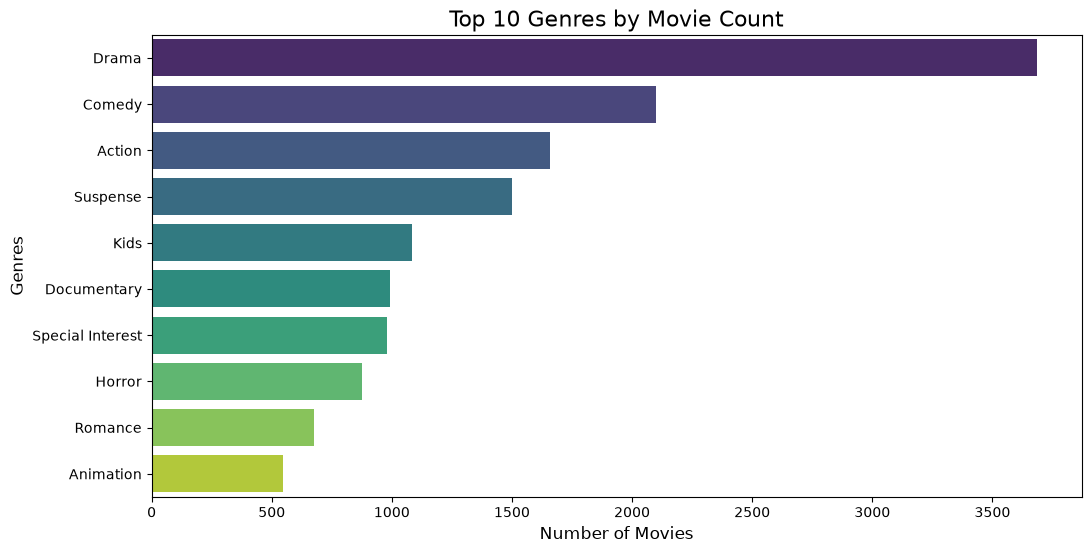

In [30]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Genre', data=genre_df.head(10), palette='viridis')
plt.title('Top 10 Genres by Movie Count', fontsize=16)
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genres', fontsize=12)
plt.show()

In [31]:
df['metadata'] = df['director'] + ' ' + df['cast'] + ' ' + df['listed_in'] + ' ' + df['description']

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import NearestNeighbors



In [33]:
vectorizer = CountVectorizer(stop_words='english')
feature_matrix = vectorizer.fit_transform(df['metadata'])

In [34]:
knn = NearestNeighbors(metric='cosine', algorithm='brute')
knn.fit(feature_matrix)

,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'cosine'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


In [35]:
def recommend_movies_knn(title, df=df, knn=knn, feature_matrix=feature_matrix, top_n=10):
   
    indices = pd.Series(df.index, index=df['title']).drop_duplicates()
    if title not in indices:
        return f"Movie '{title}' not found in the dataset."

    idx = indices[title]

    
    distances, indices = knn.kneighbors(feature_matrix[idx], n_neighbors=top_n+1)

   
    recommended_movies = df['title'].iloc[indices.flatten()]
    recommended_movies = recommended_movies[1:]  

    return recommended_movies

In [41]:
movie_name = "The North Star"  
recommended = recommend_movies_knn(movie_name)
print(f"Movies recommended for '{movie_name}':\n{recommended}")


Movies recommended for 'The North Star':
6143                         Crimson Romance
3420    A French Village (English subtitled)
6613                              I Want You
9578                       Suicide Commandos
1465                      Nurse Edith Cavell
167                         Waiting for Anya
2370                          Generation War
0                        The Grand Seduction
5966                              Chittibabu
6793                       The German Doctor
Name: title, dtype: str


In [44]:
movie_name = input("Enter a movie name: ")

recommended = recommend_movies_knn(movie_name)

print(f"\nMovies recommended for '{movie_name}':")
print(recommended)


Movies recommended for 'I Want You':
2579                      Edge of Doom
4762                     Salmonberries
1555                  My Foolish Heart
2615               Down East Dickering
7312                       Frankenfish
508                     The North Star
1061                 Seed of Innocence
2092    Invasion of the Body Snatchers
6312                 By Love Possessed
1703                     Mayor Cupcake
Name: title, dtype: str
